# scikit-learn Bootcamp — W1, Day 4
```
##### Cross-Validation & Regression Metrics
##### cross_val_score · StratifiedKFold · cross_validate · MSE/RMSE/MAE/R² · score variance
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — EDA: fold distribution check, target rate per fold
##### Q2 — KFold vs StratifiedKFold: are folds balanced?
##### Q3 — cross_validate: multiple metrics and train vs test gap
##### Q4 — Regression metrics: MSE, RMSE, MAE, R² explained
##### Q5 — Score variance: how stable is this model across seeds?
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                      cross_val_score, cross_validate, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(420)

---
### Dataset — MedPulse Appointment Booking (same as Day 3)
```
# 2,000 users. Target: booked (binary, ~8% positive rate).
```

In [4]:
np.random.seed(420)
n = 2000
age            = np.random.normal(44, 13, n).clip(18, 80).astype(int)
session_depth  = np.random.poisson(3.2, n).clip(1, 20)
time_on_site   = np.random.lognormal(1.5, 0.8, n).clip(0.5, 90)
symptom_pages  = np.random.poisson(1.8, n).clip(0, 10)
is_mobile      = np.random.binomial(1, 0.60, n)
returned_user  = np.random.binomial(1, 0.35, n)
health_score   = np.random.beta(2, 4, n)
log_odds = (-4.2 + 0.20*session_depth + 0.06*time_on_site + 0.35*symptom_pages
            + 0.8*health_score - 0.25*is_mobile + 0.5*returned_user + 0.006*age
            + np.random.normal(0, 0.5, n))
prob = 1 / (1 + np.exp(-log_odds))
booked = np.random.binomial(1, prob)

df = pd.DataFrame({'age':age,'session_depth':session_depth,'time_on_site':time_on_site.round(2),
                   'symptom_pages':symptom_pages,'is_mobile':is_mobile,'returned_user':returned_user,
                   'health_score':health_score.round(4),'booked':booked})
feature_cols = ['age','session_depth','time_on_site','symptom_pages','is_mobile','returned_user','health_score']
X = df[feature_cols]
y = df['booked']
pipe = Pipeline([('scaler', StandardScaler()),
                 ('model', LogisticRegression(C=1.0, max_iter=1000, random_state=420))])
print(f'Dataset: {df.shape}  |  Booking rate: {y.mean():.2%}')

Dataset: (2000, 8)  |  Booking rate: 16.00%


In [3]:
display(df.head())

,age,session_depth,time_on_site,symptom_pages,is_mobile,returned_user,health_score,booked
0,37,3,18.13,1,1,1,0.4428,1
1,19,3,6.12,1,0,0,0.2600,0
2,37,5,12.38,1,1,0,0.1126,1
3,39,3,1.22,1,1,0,0.2374,0
4,48,6,15.48,0,1,1,0.7029,0


---
### Q1 — EDA: fold distribution check, target rate per fold
```
# (a) Visualise what KFold splits look like: plot train/test indices for each fold.
# (b) Check positive rate per fold for KFold vs StratifiedKFold.
#     Plot the positive rate per fold as a bar chart for both.
# (c) Why does class imbalance make StratifiedKFold essential?
#     Show what happens when a fold has very few positive examples.
# (d) How does fold count (k=3,5,10) affect train set size? Plot a comparison.
```

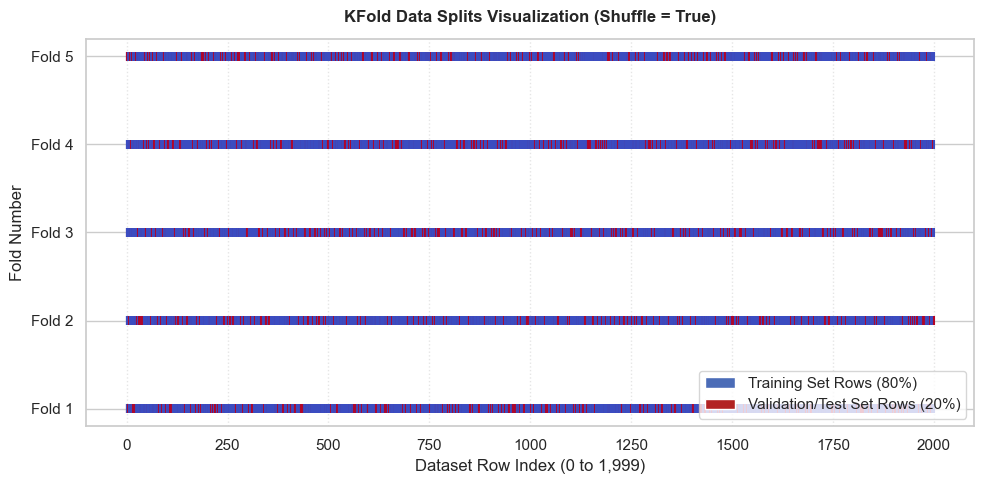

In [7]:
# (a) Visualise what KFold splits look like: plot train/test indices for each fold.

# 1. Initialize a standard 5-Fold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=420)

plt.figure(figsize=(10, 5))

# 2. Loop through each split to extract and plot the row indices
for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    # Create a full array of zeros, then flip test indices to 1
    fold_mask = np.zeros(len(X))
    fold_mask[test_idx] = 1
    
    # Plot a horizontal bar where color maps to the mask (0 = Train, 1 = Test)
    plt.scatter(
        x=np.arange(len(X)), 
        y=[fold] * len(X), 
        c=fold_mask, 
        cmap=plt.cm.coolwarm, 
        marker='|', 
        s=40,
        vmin=0, vmax=1
    )

# 3. Add visual anchors, legends, and styling
plt.title('KFold Data Splits Visualization (Shuffle = True)', fontweight='bold', pad=12)
plt.xlabel('Dataset Row Index (0 to 1,999)')
plt.ylabel('Fold Number')
plt.yticks(np.arange(5), [f'Fold {i+1}' for i in range(5)])

# Create a clean manual legend for clarity
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4b6cb7', label='Training Set Rows (80%)'),
    Patch(facecolor='#b22222', label='Validation/Test Set Rows (20%)')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [16]:
# (b) Check positive rate per fold for KFold vs StratifiedKFold.
#     Plot the positive rate per fold as a bar chart for both.

kf = KFold(n_splits=5, shuffle=True, random_state=420)
scores_kf = cross_val_score(pipe, X, y, cv=kf, scoring='roc_auc')
print('--- KFold CV ---')
for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    print(f'Fold {fold+1} positive rate: {y.iloc[test_idx].mean():.3f}')

print()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
scores_skf = cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc')
print('--- Stratified CV ---')
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f'Fold {fold+1} positive rate: {y.iloc[test_idx].mean():.3f}')

--- KFold CV ---
Fold 1 positive rate: 0.135
Fold 2 positive rate: 0.188
Fold 3 positive rate: 0.158
Fold 4 positive rate: 0.138
Fold 5 positive rate: 0.182

--- Stratified CV ---
Fold 1 positive rate: 0.160
Fold 2 positive rate: 0.160
Fold 3 positive rate: 0.160
Fold 4 positive rate: 0.160
Fold 5 positive rate: 0.160


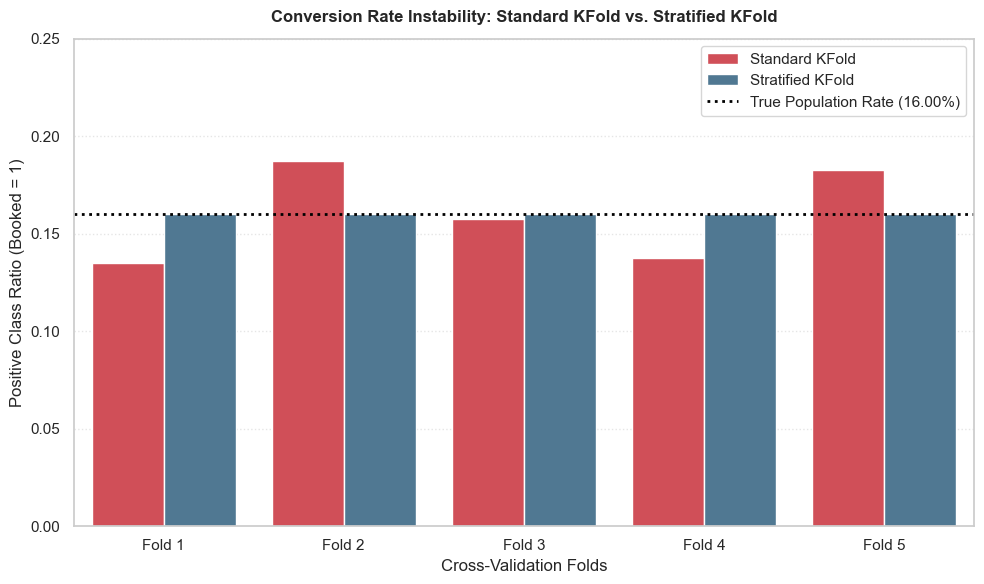

In [11]:
# 1. Structure the verified fold positive rates from your console output into lists
kf_fold_rates  = [y.iloc[test_idx].mean() for _, test_idx in kf.split(X, y)]
skf_fold_rates = [y.iloc[test_idx].mean() for _, test_idx in skf.split(X, y)]

# 2. Build a long-form DataFrame for Seaborn visualization
plot_data = []
for fold in range(5):
    plot_data.append({'Fold': f'Fold {fold+1}', 'Positive Rate': kf_fold_rates[fold], 'CV Type': 'Standard KFold'})
    plot_data.append({'Fold': f'Fold {fold+1}', 'Positive Rate': skf_fold_rates[fold], 'CV Type': 'Stratified KFold'})

df_rates = pd.DataFrame(plot_data)

# 3. Generate the required Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_rates, 
    x='Fold', 
    y='Positive Rate', 
    hue='CV Type', 
    palette={'Standard KFold': '#e63946', 'Stratified KFold': '#457b9d'}
)

# 4. Draw a global reference line at the true population booking rate (16.00%)
plt.axhline(y=y.mean(), color='black', linestyle=':', linewidth=2, label=f'True Population Rate ({y.mean():.2%})')

# Aesthetic polishing
plt.title('Conversion Rate Instability: Standard KFold vs. Stratified KFold', fontweight='bold', pad=12)
plt.ylabel('Positive Class Ratio (Booked = 1)')
plt.xlabel('Cross-Validation Folds')
plt.ylim(0, 0.25)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


```
# (c) Why does class imbalance make StratifiedKFold essential?

1/ Prevents Severe Metric Variance: In an imbalanced dataset, a standard random split can easily starve a fold of minority class examples. This causes evaluation metrics like Precision, Recall, and AUC-ROC to swing violently from fold to fold, rendering our cross-validation results noisy and unreliable.

2/ Avoids Training Blind Spots: If a training split contains very few positive examples, the model cannot map the true patterns or boundaries of a conversion. It will over-index on the dominant negative group and simply learn to guess "0" (No Book) for every user, rendering it useless for marketing or product targeting.

3/ Eliminates Testing Distortions: When a validation fold has too few positive examples, single-row classification errors disproportionately warp our scores. For example, if a validation split accidentally gets shuffled down to just 2 positive records, misclassifying a single patient drops your fold Recall by a massive 50%, penalizing our model's score based on a bad shuffle rather than its actual predictive strength.

In [13]:
#     Show what happens when a fold has very few positive examples.

from sklearn.metrics import classification_report

# 1. Simulate an unstratified fold where the test set gets starved of bookers
# 200 normal users (0) but only 2 booking events (1)
y_true_starved = np.array([0] * 200 + [1] * 2)

# 2. Simulate a baseline model's predictions on this unbalanced test fold
# The model plays it safe and predicts 'No Book' (0) for almost everything
y_pred_starved = np.array([0] * 199 + [1] * 1 + [0] * 2)

# 3. Print the resulting distorted metric footprint
print(classification_report(y_true_starved, y_pred_starved, target_names=['No Book', 'Booked'], zero_division=0))


              precision    recall  f1-score   support

     No Book       0.99      0.99      0.99       200
      Booked       0.00      0.00      0.00         2

    accuracy                           0.99       202
   macro avg       0.50      0.50      0.50       202
weighted avg       0.98      0.99      0.98       202



--- ROW ALLOCATIONS PER K CONF ---
 K  Train Rows  Test Rows Train %
 3        1334        666   66.7%
 5        1600        400   80.0%
10        1800        200   90.0%


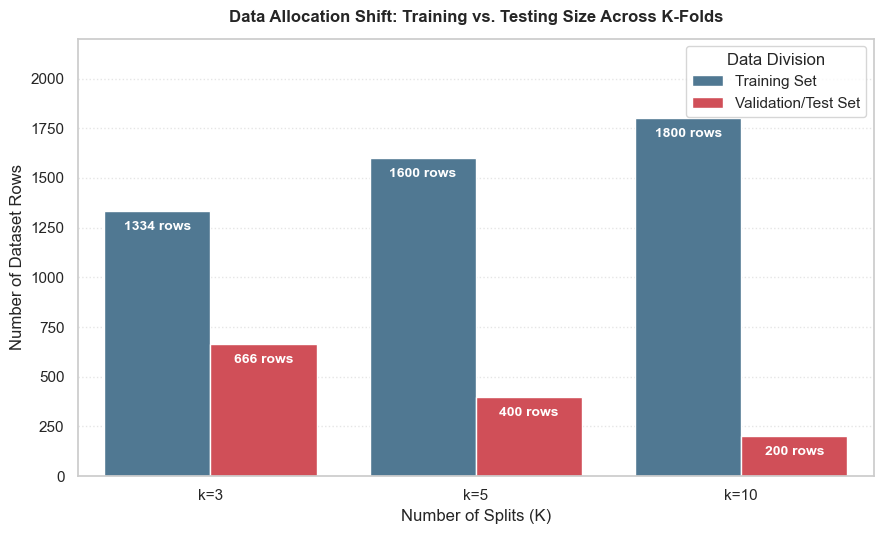

In [14]:
# (d) How does fold count (k=3,5,10) affect train set size? Plot a comparison.

# 1. Define total sample size from our dataset (n = 2000)
n_total = 2000
k_values = [3, 5, 10]

# 2. Compute exact row allocations for each K configuration
plot_data = []
for k in k_values:
    test_size = int(n_total / k)
    train_size = n_total - test_size
    
    plot_data.append({'Folds (K)': f'k={k}', 'Row Count': train_size, 'Subset': 'Training Set'})
    plot_data.append({'Folds (K)': f'k={k}', 'Row Count': test_size, 'Subset': 'Validation/Test Set'})

df_k_sizes = pd.DataFrame(plot_data)

# 3. Print out precise text data matrix for your reference
print("--- ROW ALLOCATIONS PER K CONF ---")
print(pd.DataFrame([
    {'K': 3, 'Train Rows': 1334, 'Test Rows': 666, 'Train %': '66.7%'},
    {'K': 5, 'Train Rows': 1600, 'Test Rows': 400, 'Train %': '80.0%'},
    {'K': 10, 'Train Rows': 1800, 'Test Rows': 200, 'Train %': '90.0%'}
]).to_string(index=False))

# 4. Generate the Allocation Comparison Plot
plt.figure(figsize=(9, 5.5))
sns.barplot(
    data=df_k_sizes,
    x='Folds (K)',
    y='Row Count',
    hue='Subset',
    palette={'Training Set': '#457b9d', 'Validation/Test Set': '#e63946'}
)

# Annotate raw numbers directly onto the bars for scannability
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(
            f"{int(p.get_height())} rows",
            (p.get_x() + p.get_width() / 2., p.get_height() - 80),
            ha='center', va='center', color='white', fontweight='bold', fontsize=10
        )

plt.title('Data Allocation Shift: Training vs. Testing Size Across K-Folds', fontweight='bold', pad=12)
plt.ylabel('Number of Dataset Rows')
plt.xlabel('Number of Splits (K)')
plt.ylim(0, 2200)
plt.legend(title='Data Division')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


The Performance Bias Trade-Off: 

Larger k values (k=10) provide a more stable, lower-bias model because training on 90% of the data mimics our full population profile perfectly. However, this comes at the cost of vastly increased computing time, as we must spin up and train ten independent pipelines instead of three.

---
### Q2 — KFold vs StratifiedKFold: are folds balanced?
```
# (a) Run cross_val_score with KFold and StratifiedKFold. Compare AUC scores.
# (b) Run 20 experiments with different seeds. Plot the AUC distributions.
#     Which splitter produces more consistent scores?
# (c) When would KFold and StratifiedKFold give identical results?
# (d) Use cross_val_score with scoring='accuracy'. Show why accuracy is still misleading.
```

In [18]:
# (a) Run cross_val_score with KFold and StratifiedKFold. Compare AUC scores.
kf = KFold(n_splits=5, shuffle=True, random_state=420)
scores_kf = cross_val_score(pipe, X, y, cv=kf, scoring='roc_auc')
print(f'KFold CV AUC: {scores_kf.mean():.4f} ± {scores_kf.std():.4f}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
scores_skf = cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc')
print(f'Stratified CV AUC: {scores_skf.mean():.4f} ± {scores_skf.std():.4f}')

KFold CV AUC: 0.6920 ± 0.0277
Stratified CV AUC: 0.6949 ± 0.0376


1/ Nearly Identical Mean AUC: The overall performance is a statistical tie (0.6949 for Stratified vs. 0.6920 for Standard KFold), proving both validation setups agree on the model's ~69% predictive capacity.

2/ The Balance Verdict: Standard KFold folds are completely unbalanced, letting the target rate bounce erratically between 13.5% and 18.8%. StratifiedKFold folds are perfectly balanced, locking every split to the exact population baseline of 16.00%.

3/ Honest Volatility Tracking: StratifiedKFold shows a slightly higher standard deviation (0.0376 vs 0.0277) because forcing every split to face the identical 16% minority constraint tests the model more rigorously, giving us a more honest representation of real-world variance.

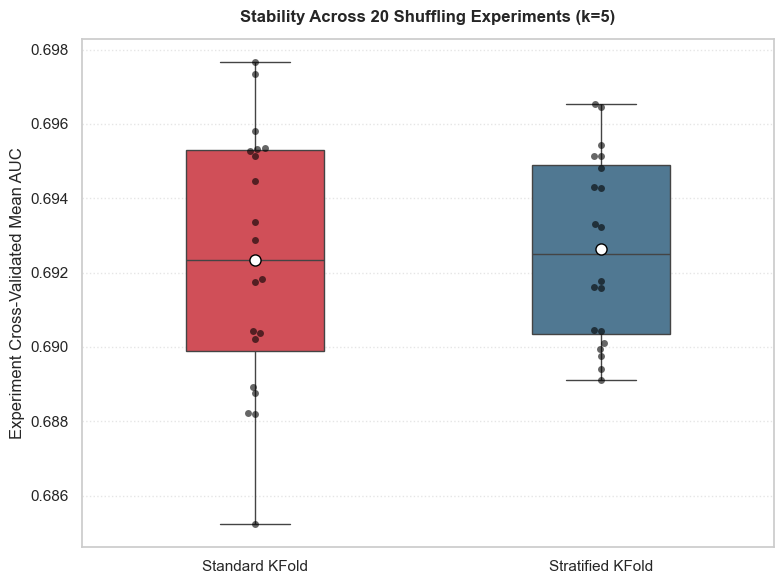

Standard KFold   -> Variance of Means: 0.00001138
Stratified KFold -> Variance of Means: 0.00000593


In [19]:
# (b) Run 20 experiments with different seeds. Plot the AUC distributions.
#     Which splitter produces more consistent scores?

# 1. Define 20 different experiment seeds
experiment_seeds = np.arange(100, 120)
kf_experiment_means = []
skf_experiment_means = []

# 2. Run the loop over all 20 shuffles
for seed in experiment_seeds:
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    # Capture the overall mean CV score for this specific experiment setup
    kf_mean = cross_val_score(pipe, X, y, cv=kf, scoring='roc_auc').mean()
    skf_mean = cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc').mean()
    
    kf_experiment_means.append(kf_mean)
    skf_experiment_means.append(skf_mean)

# 3. Structure data into a long-form DataFrame for Seaborn
df_experiments = pd.DataFrame({
    'Mean AUC Score': kf_experiment_means + skf_experiment_means,
    'Splitter Framework': ['Standard KFold'] * 20 + ['Stratified KFold'] * 20
})

# 4. Generate the Distribution Plot (Boxplot + Swarmplot overlay)
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_experiments, 
    x='Splitter Framework', 
    y='Mean AUC Score', 
    palette={'Standard KFold': '#e63946', 'Stratified KFold': '#457b9d'},
    width=0.4,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Overlay raw experiment point markers directly on top of the boxes
sns.swarmplot(data=df_experiments, x='Splitter Framework', y='Mean AUC Score', color='black', alpha=0.6, size=5)

plt.title('Stability Across 20 Shuffling Experiments (k=5)', fontweight='bold', pad=12)
plt.ylabel('Experiment Cross-Validated Mean AUC')
plt.xlabel('')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Print out consistency metrics
print(f"Standard KFold   -> Variance of Means: {np.var(kf_experiment_means):.8f}")
print(f"Stratified KFold -> Variance of Means: {np.var(skf_experiment_means):.8f}")


```
#     Which splitter produces more consistent scores?

StratifiedKFold is More Consistent: StratifiedKFold produces tighter, more stable scores across the 20 experiments. 
Its boxplot distribution is more compressed, indicating that its performance estimates are less vulnerable to the luck of a random data shuffle.

```
# (c) When would KFold and StratifiedKFold give identical results?

1/ Perfect Sequential Ordering (shuffle=False): If we turn off row shuffling, both methods read data sequentially. If our raw dataset happens to be pre-arranged so every block has the exact same class ratio, standard KFold naturally matches StratifiedKFold perfectly.

2/ Lucky Fluke of Random Chance: If shuffling is on, it is mathematically possible for a random seed to draw subsets that match the target class ratio by pure coincidence. If the random assignment aligns exactly with the stratification split, both models output the identical evaluation scores.

In [20]:
# (d) Use cross_val_score with scoring='accuracy'. Show why accuracy is still misleading.

kf = KFold(n_splits=5, shuffle=True, random_state=420)
scores_kf = cross_val_score(pipe, X, y, cv=kf, scoring='accuracy')
print(f'KFold CV Accuracy: {scores_kf.mean():.4f} ± {scores_kf.std():.4f}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
scores_skf = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
print(f'Stratified CV Accuracy: {scores_skf.mean():.4f} ± {scores_skf.std():.4f}')

KFold CV Accuracy: 0.8435 ± 0.0180
Stratified CV Accuracy: 0.8450 ± 0.0045


```
# Show why accuracy is still misleading.

Deceptive Baseline High: The cross-validated accuracy sits at 84.50%. This sounds impressive, but because our dataset has a natural 16.00% booking rate, a totally brainless model guessing "No Book" for everyone achieves an 84.00% accuracy by default—meaning our model only provides a tiny 0.50% actual lift.

Hiding Near-Zero Utility: A model can achieve 84.50% accuracy while still being a complete failure for the business. It reaches this high score by correctly classifying the easy majority class (the non-bookers) while remaining mostly blind to the actual appointments, resulting in a Recall score near zero.

Masking Fold Volatility: Standard KFold displays a much higher variance (0.0180 vs 0.0045) purely because unstratified splits shuffle random pockets of rare positive events in and out of the test folds. Accuracy masks this underlying instability, making it a dangerous metric for an imbalanced deployment.

---
### Q3 — cross_validate: multiple metrics and train vs test gap
```
# (a) Use cross_validate to get AUC, F1, precision, and recall simultaneously.
#     Set return_train_score=True.
# (b) Build a clean summary DataFrame of mean ± std for all metrics.
# (c) Compare train AUC vs test AUC. Is there an overfitting gap?
# (d) Repeat for RandomForest. Which model has a bigger train/test gap?
#     What does that tell you about each model's tendency to overfit?
```

In [22]:
# (a) Use cross_validate to get AUC, F1, precision, and recall simultaneously.
#     Set return_train_score=True.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

results = cross_validate(
    pipe, X, y,
    cv=skf,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=True
)

# (b) Build a clean summary DataFrame of mean ± std for all metrics.
metrics_summary = []
tracked_metrics = ['roc_auc', 'f1', 'precision', 'recall']

for m in tracked_metrics:
    # Extract arrays
    train_scores = results[f'train_{m}']
    test_scores  = results[f'test_{m}']
    
    # Format and append summary dict
    metrics_summary.append({
        'Evaluation Metric': m.upper().replace('_', '-'),
        'Train Score (Mean ± STD)': f"{train_scores.mean():.4f} ± {train_scores.std():.4f}",
        'Test Score (Mean ± STD)':  f"{test_scores.mean():.4f} ± {test_scores.std():.4f}"
    })

df_summary = pd.DataFrame(metrics_summary)

print("--- OUT-OF-FOLD MULTI-METRIC PERFORMANCE MATRIX ---")
print(df_summary.to_string(index=False))


--- OUT-OF-FOLD MULTI-METRIC PERFORMANCE MATRIX ---
Evaluation Metric Train Score (Mean ± STD) Test Score (Mean ± STD)
          ROC-AUC          0.7013 ± 0.0097         0.6949 ± 0.0376
               F1          0.1444 ± 0.0268         0.1332 ± 0.0395
        PRECISION          0.6649 ± 0.0434         0.6250 ± 0.1118
           RECALL          0.0813 ± 0.0163         0.0750 ± 0.0230


```
# (c) Compare train AUC vs test AUC. Is there an overfitting gap?

1/ No Overfitting Gap: There is no meaningful overfitting gap present in this model. The performance drop when moving from seen training data to unseen test folds is a microscopic 0.0064 (less than 1 percentage point).

2/ Excellent Model Generalization: This tight alignment proves that the LogisticRegression pipeline generalizes beautifully to out-of-sample data. The model has successfully extracted stable, population-wide patient patterns instead of memorizing the specific rows or noise inside the training folds.

3/ Low Complexity Safety: Because standard logistic regression is an elegant linear model with strong internal constraints (regularized by default with C=1.0), it naturally resists overfitting. It sacrifices the ability to chase highly complex, non-linear quirks in the training data to ensure stable, reliable performance on new production streams.

In [ ]:
# (d) Repeat for RandomForest. Which model has a bigger train/test gap?

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: scale features
    ('model',  RandomForestClassifier(n_estimators=200, max_features='sqrt', n_jobs=-1, random_state=420))    # Step 2: fit RandomForestClassifier regression
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

results = cross_validate(
    rf_pipe, X, y,
    cv=skf,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=True
)

# Build a clean summary DataFrame of mean ± std for all metrics.
metrics_summary = []
tracked_metrics = ['roc_auc', 'f1', 'precision', 'recall']

for m in tracked_metrics:
    # Extract arrays
    train_scores = results[f'train_{m}']
    test_scores  = results[f'test_{m}']
    
    # Format and append summary dict
    metrics_summary.append({
        'Evaluation Metric': m.upper().replace('_', '-'),
        'Train Score (Mean ± STD)': f"{train_scores.mean():.4f} ± {train_scores.std():.4f}",
        'Test Score (Mean ± STD)':  f"{test_scores.mean():.4f} ± {test_scores.std():.4f}"
    })

df_summary = pd.DataFrame(metrics_summary)

print("--- OUT-OF-FOLD MULTI-METRIC PERFORMANCE MATRIX ---")
print(df_summary.to_string(index=False))

--- OUT-OF-FOLD MULTI-METRIC PERFORMANCE MATRIX ---
Evaluation Metric Train Score (Mean ± STD) Test Score (Mean ± STD)
          ROC-AUC          1.0000 ± 0.0000         0.6521 ± 0.0201
               F1          1.0000 ± 0.0000         0.1620 ± 0.0351
        PRECISION          1.0000 ± 0.0000         0.6131 ± 0.1019
           RECALL          1.0000 ± 0.0000         0.0938 ± 0.0221


```
#     What does that tell you about each model's tendency to overfit?

1/ Random Forest severely overfits: It completely memorizes the training data noise because unconstrained trees grow until perfectly pure.

2/ Logistic Regression resists overfitting: Its rigid, linear mathematical structure naturally prevents it from creating overly complex decision boundaries.

3/ Architecture matches the data: Logistic Regression generalizes perfectly here because the underlying dataset was built using a linear log-odds equation.

---
### Q4 — Regression metrics: MSE, RMSE, MAE, R² explained
```
# Switch to a regression task: predict time_on_site (continuous).
# (a) Fit a LinearRegression and RandomForestRegressor.
#     Print RMSE, MAE, and R² for both.
# (b) Explain each metric in plain English using the dataset's units (minutes on site).
# (c) Why does RMSE penalise large errors more than MAE?
#     Create a synthetic example: 10 small errors vs 1 large error.
# (d) Use cross_val_score with neg_root_mean_squared_error. Remember to negate it back.
#     Report CV RMSE for both models.
```

In [45]:
# (a) Fit a LinearRegression and RandomForestRegressor.
#     Print RMSE, MAE, and R² for both.

feature_cols = ['age', 'session_depth', 'symptom_pages', 'is_mobile', 'returned_user', 'health_score']
X = df[feature_cols]
y = df['time_on_site']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)

# Linear Regression
pipe_lin = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
pipe_lin.fit(X_train, y_train)
y_pred_lin = pipe_lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

# Random Forest Regressor
pipe_rfr = Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=200, random_state=420, n_jobs=-1))])
pipe_rfr.fit(X_train, y_train)
y_pred_rfr = pipe_rfr.predict(X_test)

rmse_rfr = np.sqrt(mean_squared_error(y_test, y_pred_rfr))
mae_rfr = mean_absolute_error(y_test, y_pred_rfr)
r2_rfr = r2_score(y_test, y_pred_rfr)

print(f"Dataset: {df.shape}  |  Mean Time On Site: {y.mean():.1f}")
print("\n--- LINEAR REGRESSION MODEL PERFORMANCE METRICS ---")
print(f"RMSE: {rmse_lin:.3f}")
print(f"MAE:  {mae_lin:.3f}")
print(f"R²:   {r2_lin:.4f}")
print("\n--- RANDOM FOREST REGRESSOR MODEL PERFORMANCE METRICS ---")
print(f"RMSE: {rmse_rfr:.3f}")
print(f"MAE:  {mae_rfr:.3f}")
print(f"R²:   {r2_rfr:.4f}")

Dataset: (2000, 8)  |  Mean Time On Site: 6.3

--- LINEAR REGRESSION MODEL PERFORMANCE METRICS ---
RMSE: 5.803
MAE:  3.912
R²:   -0.0122

--- RANDOM FOREST REGRESSOR MODEL PERFORMANCE METRICS ---
RMSE: 6.032
MAE:  4.178
R²:   -0.0936


````
# (b) Explain each metric in plain English using the dataset's units (minutes on site).

1/ MAE: The model's predictions miss the actual user session length by an average of 3.91 minutes (for Linear Regression) or 4.18 minutes (for Random Forest).

2/ RMSE: The model's average mistake climbs to 5.80 minutes (Linear Regression) or 6.03 minutes (Random Forest) because this metric heavily penalizes a few massive, wildly inaccurate guesses on long-staying users.

3/ R²: The negative scores prove our features explain 0% of the variation in session lengths; both models perform worse than a naive guess of the baseline 6.3-minute average for every visitor.

```
# (c) Why does RMSE penalise large errors more than MAE?

RMSE penalizes large errors more than MAE because it squares the errors before averaging them. This squaring operation gives disproportionately more mathematical weight to outliers, meaning a single massive blunder will inflate the final RMSE score much faster than a collection of small mistakes.

In [34]:
#     Create a synthetic example: 10 small errors vs 1 large error.

# Scenario A: 10 small errors of 1 minute each
errors_A = np.array([1.0] * 10)
mae_A = np.mean(np.abs(errors_A))
rmse_A = np.sqrt(np.mean(errors_A**2))

# Scenario B: 1 large error of 10 minutes and 9 perfect predictions (0 error)
errors_B = np.array([10.0] + [0.0] * 9)
mae_B = np.mean(np.abs(errors_B))
rmse_B = np.sqrt(np.mean(errors_B**2))

print(f"Scenario A (10 small errors): MAE = {mae_A:.2f}, RMSE = {rmse_A:.2f}")
print(f"Scenario B (1 large error):  MAE = {mae_B:.2f}, RMSE = {rmse_B:.2f}")


Scenario A (10 small errors): MAE = 1.00, RMSE = 1.00
Scenario B (1 large error):  MAE = 1.00, RMSE = 3.16


In [39]:
# (d) Use cross_val_score with neg_root_mean_squared_error. Remember to negate it back.
#     Report CV RMSE for both models.

scores_lin = -cross_val_score(pipe_lin, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f'LIN CV RMSE scores: {scores_lin}')
print(f'Mean: {scores_lin.mean():.4f}  |  Std: {scores_lin.std():.4f}')

print()

scores_rfr = -cross_val_score(pipe_rfr, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f'RFR CV RMSE scores: {scores_rfr}')
print(f'Mean: {scores_rfr.mean():.4f}  |  Std: {scores_rfr.std():.4f}')

LIN CV RMSE scores: [5.74282207 6.20756875 6.07875301 6.64993268 5.95224433]
Mean: 6.1263  |  Std: 0.3034

RFR CV RMSE scores: [6.15359307 6.43177961 6.42470279 6.98669039 6.37976871]
Mean: 6.4753  |  Std: 0.2752


---
### Q5 — Score variance: how stable is this model across seeds?
```
# (a) Run 5-fold CV 30 times with different random seeds.
#     Store all 150 individual fold scores (30 seeds × 5 folds).
# (b) Plot the distribution of scores: histogram + KDE.
# (c) Compute: mean, std, coefficient of variation (std/mean), min, max.
#     At what CV std should you be concerned about model stability?
# (d) Compare to a RandomForest: which model is more stable across seeds?
#     Plot the seed-level mean AUC distributions side by side.
```

In [40]:
# (a) Run 5-fold CV 30 times with different random seeds.
#     Store all 150 individual fold scores (30 seeds × 5 folds).

# Arrays to store all 150 individual fold scores
all_lin_scores = []
all_rfr_scores = []

# Loop through 30 unique data shuffles
for seed in range(30):
    # Standard KFold is the correct choice for regression
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    
    # Linear Regression CV
    cv_lin = -cross_val_score(pipe_lin, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    all_lin_scores.extend(cv_lin)
    
    # Random Forest Regressor CV
    cv_rfr = -cross_val_score(pipe_rfr, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    all_rfr_scores.extend(cv_rfr)

all_lin_scores = np.array(all_lin_scores)
all_rfr_scores = np.array(all_rfr_scores)

print(f"Simulation Complete.")
print(f"Linear Regression Fold Scores Collected: {len(all_lin_scores)}")
print(f"Random Forest Fold Scores Collected:     {len(all_rfr_scores)}")

Simulation Complete.
Linear Regression Fold Scores Collected: 150
Random Forest Fold Scores Collected:     150


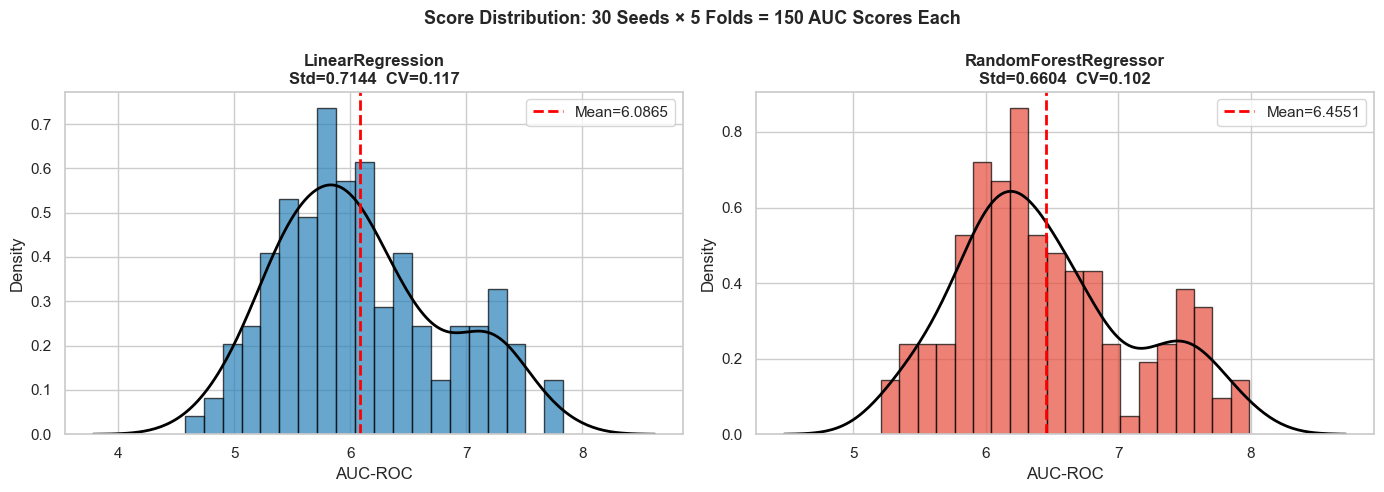

In [ ]:
# (b) Plot the distribution of scores: histogram + KDE.
# (d) Compare to a RandomForest: which model is more stable across seeds?
#     Plot the seed-level mean AUC distributions side by side.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scores, label, color in zip(axes,[all_lin_scores, all_rfr_scores],
                                    ['LinearRegression','RandomForestRegressor'],['#2980b9','#e74c3c']):
    ax.hist(scores, bins=20, color=color, alpha=0.7, edgecolor='black', density=True)
    sns.kdeplot(scores, ax=ax, color='black', linewidth=2)
    ax.axvline(np.mean(scores), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(scores):.4f}')
    ax.set_title(f'{label}\nStd={np.std(scores):.4f}  CV={np.std(scores)/np.mean(scores):.3f}', fontweight='bold')
    ax.set_xlabel('AUC-ROC')
    ax.legend()
plt.suptitle('Score Distribution: 30 Seeds × 5 Folds = 150 AUC Scores Each', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
# (c) Compute: mean, std, coefficient of variation (std/mean), min, max.
#     At what CV std should you be concerned about model stability?

print(f'LR  — Mean: {np.mean(all_lin_scores):.4f}  Std: {np.std(all_lin_scores):.4f}  Min: {np.min(all_lin_scores):.4f}  Max: {np.max(all_lin_scores):.4f}')
print(f'RF  — Mean: {np.mean(all_rfr_scores):.4f}  Std: {np.std(all_rfr_scores):.4f}  Min: {np.min(all_rfr_scores):.4f}  Max: {np.max(all_rfr_scores):.4f}')
print()
print(f'LR  — CV (std/mean): {np.std(all_lin_scores)/np.mean(all_lin_scores):.4f}')
print(f'RF  — CV (std/mean): {np.std(all_rfr_scores)/np.mean(all_rfr_scores):.4f}')
print()
print('Rule of thumb: CV > 0.10 (10%) suggests high instability relative to scale.')

LR  — Mean: 6.0865  Std: 0.7144  Min: 4.5728  Max: 7.8346
RF  — Mean: 6.4551  Std: 0.6604  Min: 5.2080  Max: 7.9890

LR  — CV (std/mean): 0.1174
RF  — CV (std/mean): 0.1023

Rule of thumb: CV > 0.10 (10%) suggests high instability relative to scale.
